# 04 · Pseudo-Label Generation

Grad-CAM heatmap từ notebook 03 cho thấy model đang nhìn đúng vùng tổn thương. Bước này chuyển hóa attention map đó thành **binary segmentation mask** — đây là pseudo-label, thay thế cho pixel-level annotation tốn công.

Pipeline: threshold heatmap → morphological post-processing (CLOSE + OPEN) → lưu mask PNG. Mỗi ảnh train sẽ có 1 mask tương ứng để dùng cho segmentation training ở notebook 05+.

---

**Những gì notebook này làm:**

1. **Load data + model** — toàn bộ 3,104 ảnh train, nạp `best_model.pth`
2. **Setup Grad-CAM** — cùng config với notebook 03
3. **Tạo pseudo-label** — threshold 0.5 + morphological CLOSE/OPEN 5×5
4. **Visualization** — Original | Grad-CAM overlay | Pseudo mask overlay (best sample/lớp)
5. **Demo morphological** — so sánh mask trước/sau post-processing
6. **Đánh giá chất lượng** — coverage, accuracy, phân phối per class

**Output:** Masks tại `data/pseudo_labels_train/` · Ảnh resize tại `data/processed_train/` · Figures tại `visualizations/pseudo_labeling/`

In [ ]:
import os
import sys
import json
proj_root = r'E:\Master\thesis-clean'
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from collections import defaultdict
import torch
from torchvision import transforms

from utils.models import EfficientNetClassifier
from utils.gradcam import GradCAMGenerator, find_efficientnet_target_layer

# Plot style — nhất quán với notebook 01-03
plt.style.use('default')
sns.set_palette("husl")

# Class metadata — nhất quán với notebook 01-03
CLASS_NAMES  = ["ALGAL_LEAF_SPOT", "ALLOCARIDARA_ATTACK", "HEALTHY_LEAF", "LEAF_BLIGHT", "PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot", "Allocaridara Attack", "Healthy Leaf", "Leaf Blight", "Phomopsis Leaf Spot"]
CLASS_COLORS = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: label for i, label in enumerate(CLASS_LABELS)}

VIZ_DIR = "visualizations/pseudo_labeling"
os.makedirs(VIZ_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Load Data + Model

Dùng cùng tập train và cùng checkpoint với notebook 03 — đảm bảo pseudo-label sinh ra từ đúng model đã được evaluate. Load `best_model.pth` (val_acc 98.19% tại epoch 11), không dùng `resume.pth`.

Lưu ý: notebook này sẽ chạy lại toàn bộ Grad-CAM pipeline trên 3,104 ảnh. Nếu đã có `pseudo_labels_train/` từ lần chạy trước thì có thể skip và dùng lại output.

In [2]:
train_dir = os.path.join(proj_root, 'notebooks', 'data', 'raw', 'train')
print(f"Train dir: {train_dir}")

selected_samples = []

for cls_name in CLASS_NAMES:
    cls_dir = Path(train_dir) / cls_name
    cls_idx = CLASS_TO_IDX[cls_name]
    imgs = sorted(list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png")))
    for img_path in imgs:
        selected_samples.append((str(img_path), cls_idx, cls_name))
    print(f"  {cls_name}: {len(imgs)} ảnh")

print(f"\nTổng: {len(selected_samples)} ảnh")

Train dir: e:\Master\thesis-clean\notebooks\data\raw\train
  ALGAL_LEAF_SPOT: 513 ảnh
  ALLOCARIDARA_ATTACK: 639 ảnh
  HEALTHY_LEAF: 683 ảnh
  LEAF_BLIGHT: 655 ảnh
  PHOMOPSIS_LEAF_SPOT: 614 ảnh

Tổng: 3104 ảnh


In [3]:
model = EfficientNetClassifier(num_classes=len(CLASS_NAMES), backbone='efficientnet_b0', pretrained=False)

ckpt_path = 'models/classification/checkpoints/best_model.pth'
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Không tìm thấy {ckpt_path}. Chạy notebook 02 trước.")

checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device).eval()
print(f"Loaded: {ckpt_path} — val_acc at save: {checkpoint.get('val_acc', 'N/A'):.4f}")

Loaded: models/classification/checkpoints/best_model.pth — val_acc at save: 0.9819


## Setup Grad-CAM

Cùng target layer và transform với notebook 03. Transform không có augmentation — cần output ổn định để tạo mask nhất quán. Nếu augment, mỗi lần chạy sẽ ra mask khác nhau.

In [4]:
target_layer = find_efficientnet_target_layer(model)
gradcam_gen = GradCAMGenerator(model, target_layer=target_layer, device=device.type)
print('Grad-CAM target layer:', target_layer)

infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Grad-CAM target layer: base.features.8.0


## Tạo Pseudo-Label

Ba bước cho mỗi ảnh:
1. **Threshold heatmap ≥ 0.5** → binary mask thô (pixel = 1 nếu attention cao)
2. **MORPH_CLOSE (5×5)** → lấp lỗ hổng nhỏ bên trong vùng bệnh
3. **MORPH_OPEN (5×5)** → loại nhiễu nhỏ bên ngoài vùng chính

Kernel 5×5 ≈ 2.2% diện tích ảnh — đủ để làm mịn mà không xóa mất vùng tổn thương nhỏ. Mỗi ảnh lưu ra hai file: ảnh gốc resize (224×224) và mask PNG nhị phân (0/255).

In [5]:
pseudo_dir = Path(os.path.join(proj_root, 'notebooks', 'data', 'pseudo_labels_train'))
processed_dir = Path(os.path.join(proj_root, 'notebooks', 'data', 'processed_train'))
pseudo_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

stats = []
results_by_class = defaultdict(list)
kernel = np.ones((5, 5), np.uint8)

for img_path, cls_idx, cls_name in tqdm(selected_samples, desc="Pseudo-label generation"):
    try:
        orig_img = Image.open(img_path).convert("RGB").resize((224, 224))
        orig_arr = np.array(orig_img)

        input_tensor = infer_transform(orig_img).unsqueeze(0).to(device)
        heatmap, confidence, pred_class = gradcam_gen.generate(input_tensor, cls_idx)

        # torchcam trả về (1, H, W) — squeeze + resize về 224×224
        heatmap_2d = np.squeeze(heatmap)
        if heatmap_2d.shape != (224, 224):
            heatmap_2d = cv2.resize(heatmap_2d, (224, 224))
        heatmap_2d = np.clip(heatmap_2d, 0, 1)

        # Tạo binary mask
        mask = (heatmap_2d >= 0.5).astype(np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        # Lưu mask + ảnh gốc
        fname = Path(img_path).name
        base_name = f"{cls_name}_{fname}"
        cv2.imwrite(str(pseudo_dir / f"{base_name}_pseudo.png"), (mask * 255).astype(np.uint8))
        orig_img.save(str(processed_dir / base_name))

        # Overlay cho visualization
        heatmap_colored = cv2.applyColorMap((heatmap_2d * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        gradcam_overlay = cv2.addWeighted(orig_arr, 0.6, heatmap_rgb, 0.4, 0)

        mask_rgb = np.zeros_like(orig_arr)
        mask_rgb[:, :, 1] = mask * 255  # green channel
        pseudo_overlay = cv2.addWeighted(orig_arr, 0.7, mask_rgb, 0.3, 0)

        stats.append({
            "filename": base_name,
            "original_path": img_path,
            "class_name": cls_name,
            "class_idx": cls_idx,
            "pred_class": pred_class,
            "confidence": float(confidence),
            "mask_coverage": float(mask.mean()),
        })
        results_by_class[cls_name].append({
            "orig_arr": orig_arr,
            "heatmap": heatmap_2d,
            "gradcam_overlay": gradcam_overlay,
            "mask": mask,
            "pseudo_overlay": pseudo_overlay,
            "confidence": float(confidence),
            "pred_class": pred_class,
            "true_class": cls_idx,
        })

    except Exception as e:
        print(f"  Lỗi {img_path}: {e}")

with open(pseudo_dir / "pseudo_label_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print(f"\nGenerated: {len(stats)} pseudo-labels")
print(f"Masks → {pseudo_dir}")
print(f"Images → {processed_dir}")

Pseudo-label generation: 100%|██████████| 3104/3104 [14:00<00:00,  3.69it/s]



Generated: 3104 pseudo-labels
Masks → e:\Master\thesis-clean\notebooks\data\pseudo_labels_train
Images → e:\Master\thesis-clean\notebooks\data\processed_train


## Visualization

Hai chart:
1. **Best sample per class** — ảnh confidence cao nhất, xem mask có khớp vùng tổn thương không
2. **Morphological demo** — so sánh mask thô (threshold only) vs. mask sau CLOSE+OPEN trên cùng một ảnh

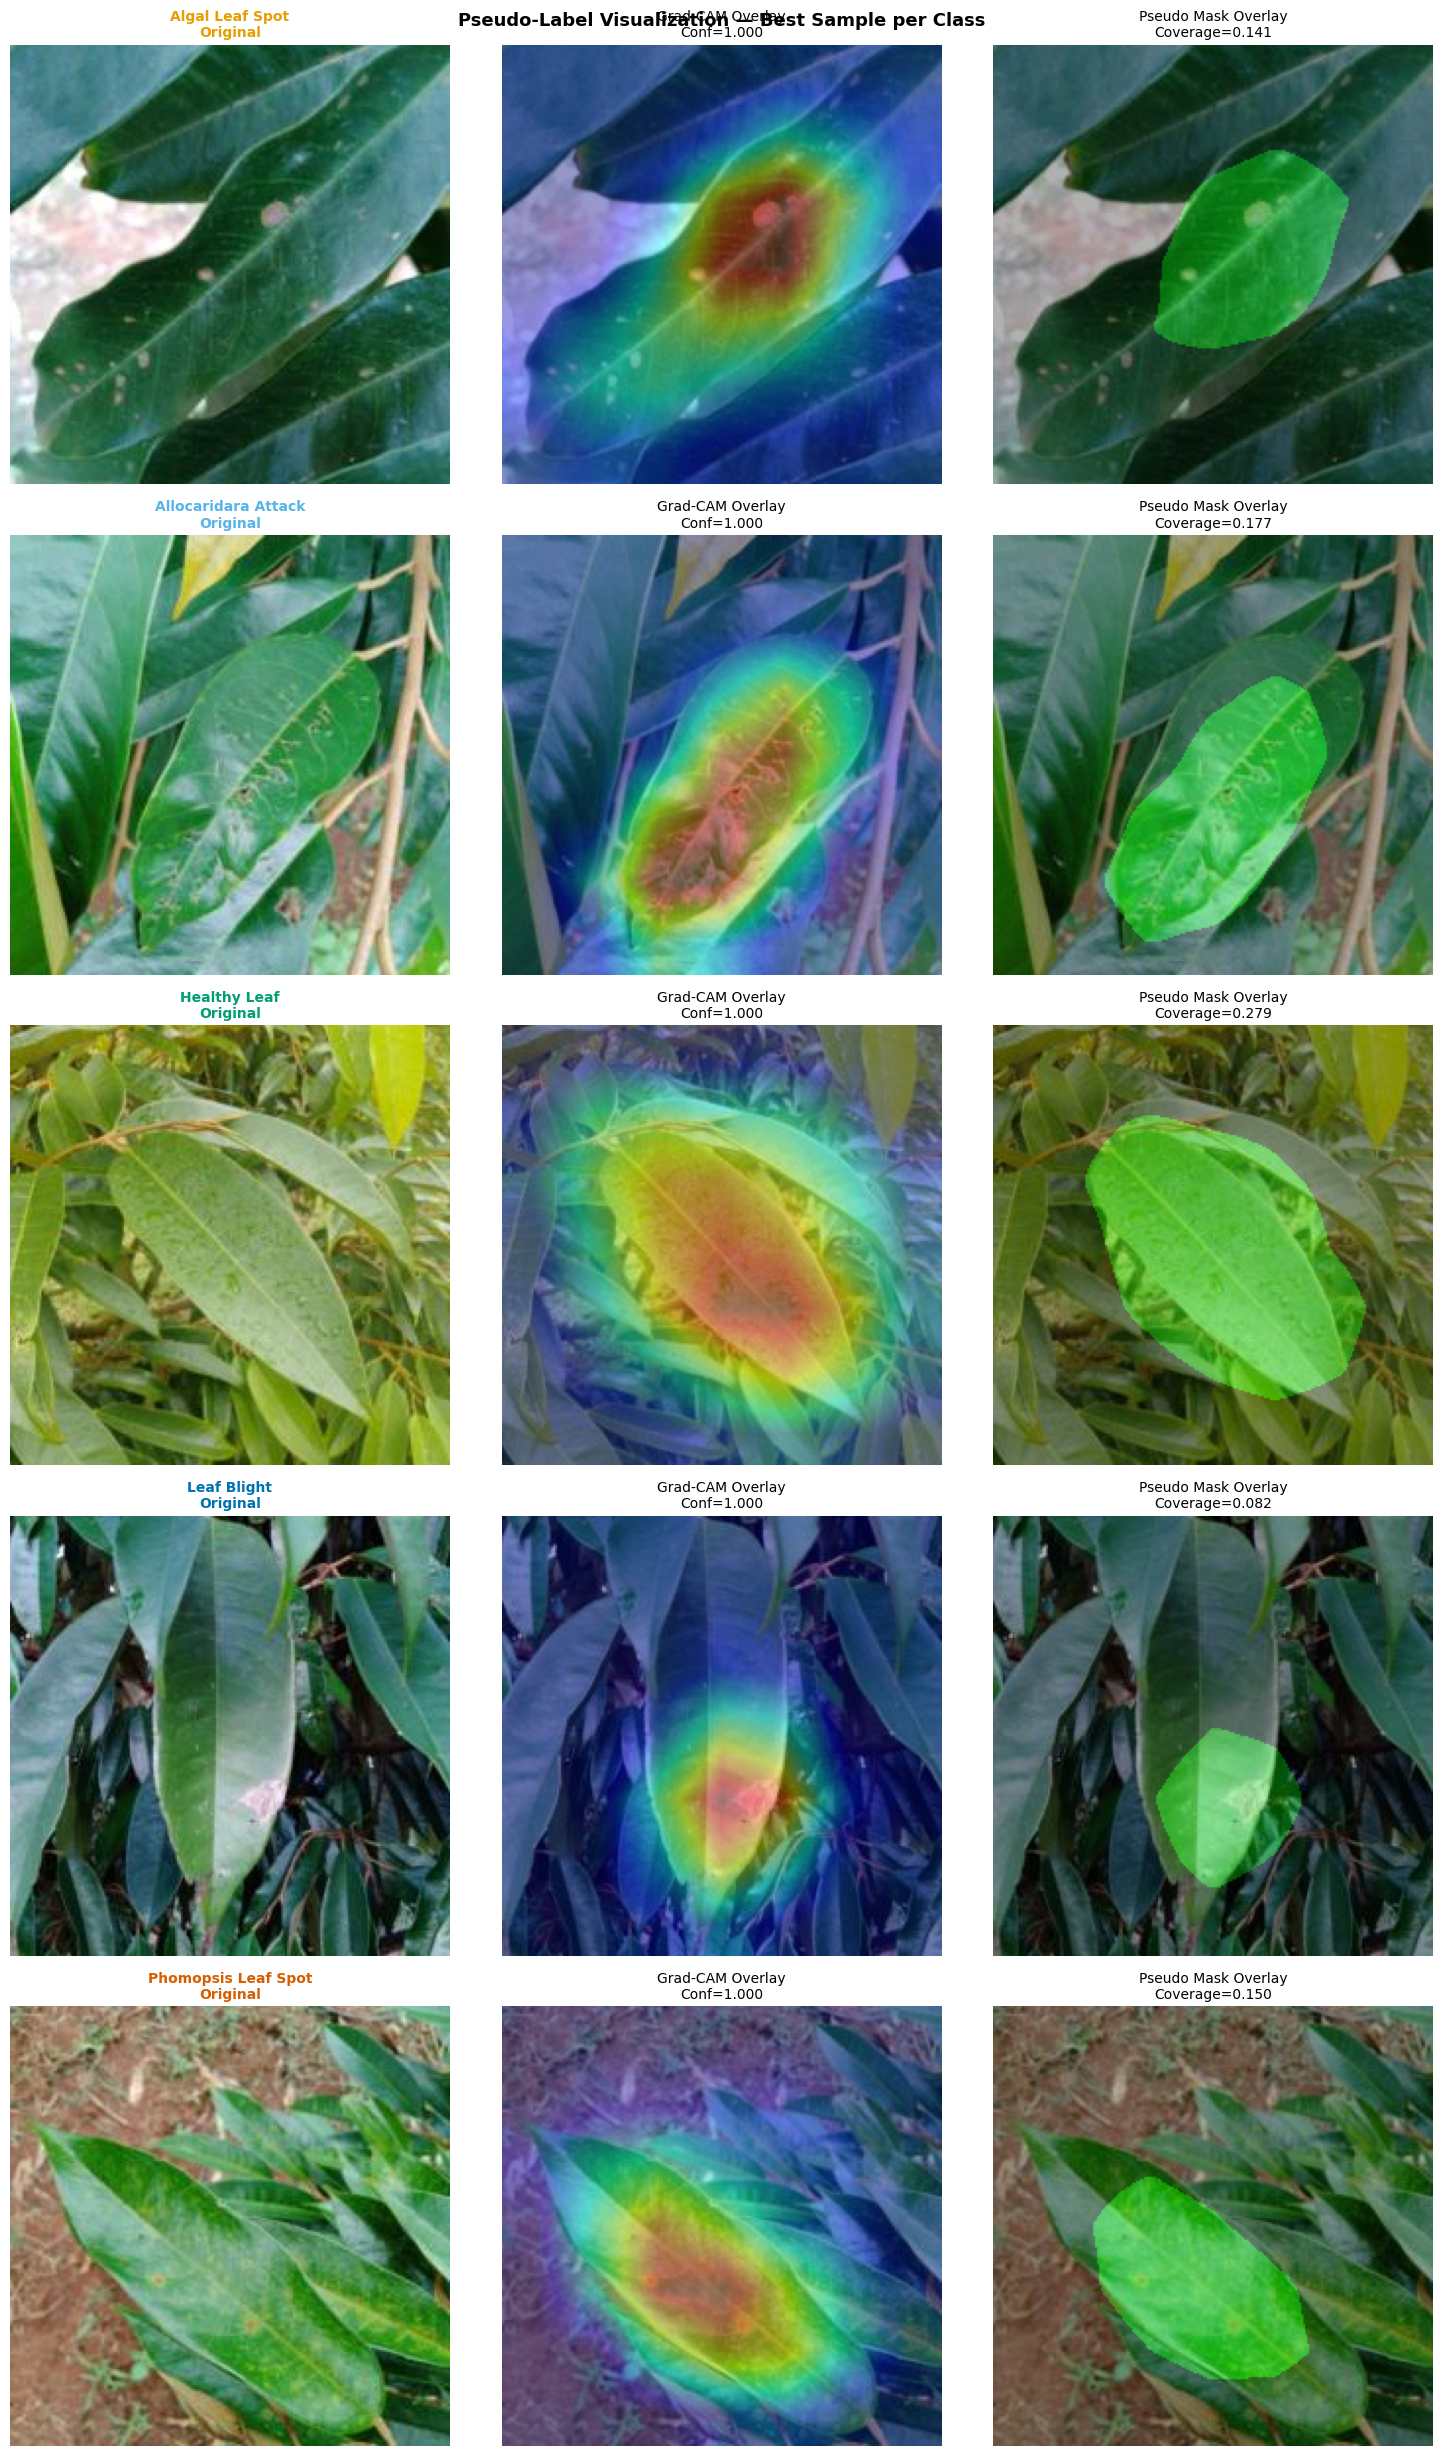

Saved → visualizations/pseudo_labeling/pseudo_label_per_class.png


In [6]:
n_classes = len(CLASS_NAMES)
fig, axes = plt.subplots(n_classes, 3, figsize=(15, 5 * n_classes))
fig.suptitle("Pseudo-Label Visualization — Best Sample per Class", fontsize=13, fontweight="bold")

for i, (cls_name, cls_label, cls_color) in enumerate(zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS)):
    items = results_by_class.get(cls_name, [])
    if not items:
        continue
    best = max(items, key=lambda x: x["confidence"])

    axes[i, 0].imshow(best["orig_arr"])
    axes[i, 0].set_title(f"{cls_label}\nOriginal", fontsize=10, fontweight="bold", color=cls_color)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(best["gradcam_overlay"])
    axes[i, 1].set_title(f"Grad-CAM Overlay\nConf={best['confidence']:.3f}", fontsize=10)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(best["pseudo_overlay"])
    axes[i, 2].set_title(f"Pseudo Mask Overlay\nCoverage={best['mask'].mean():.3f}", fontsize=10)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "pseudo_label_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/pseudo_label_per_class.png")

**Nhận xét — Pseudo-label per class:**

- **Allocaridara Attack** có mask bám sát nhất — texture vết cắn côn trùng rõ ràng, attention tập trung hơn các lớp đốm nhỏ
- **Algal / Phomopsis**: mask khoanh được vùng đốm nhưng biên rộng hơn vùng thực tế — hệ quả của Grad-CAM 7×7 upsample lên 224×224, gradient bị làm mịn khi resize
- **Leaf Blight**: mask trải rộng theo mảng hoại tử — phù hợp vì bệnh này chiếm diện tích lớn, coverage trung bình 12.3% thấp nhất trong các lớp bệnh
- **Healthy Leaf**: coverage cao nhất (mean 26.4%, max 59.1%) và không có vùng trọng tâm — model không có lesion để focus, attention khuếch tán khắp lá. Mask lớp này không mang ý nghĩa segmentation bệnh

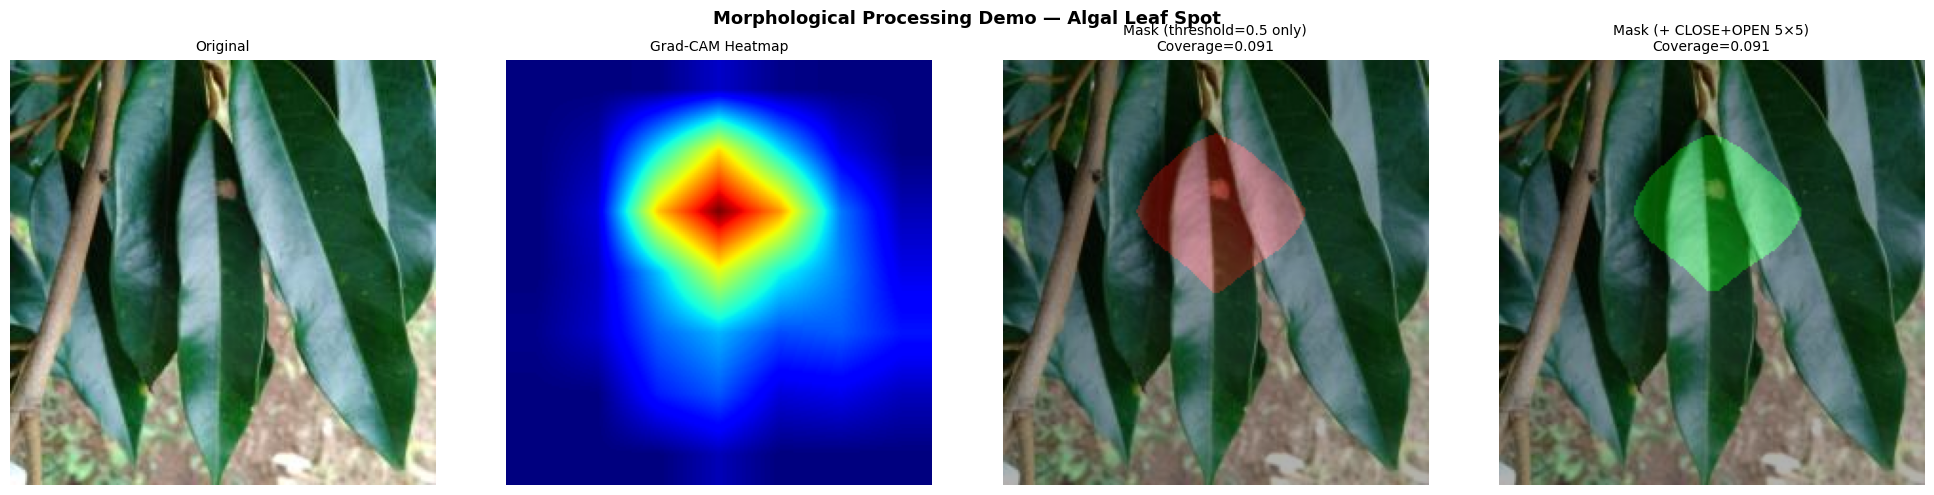

Saved → visualizations/pseudo_labeling/morphological_demo.png


In [7]:
demo_cls = CLASS_NAMES[0]
demo_items = results_by_class.get(demo_cls, [])

if demo_items:
    demo = demo_items[0]
    orig_arr = demo["orig_arr"]
    heatmap_2d = demo["heatmap"]

    mask_raw = (heatmap_2d >= 0.5).astype(np.uint8)
    mask_raw_rgb = np.zeros_like(orig_arr)
    mask_raw_rgb[:, :, 0] = mask_raw * 255  # red — mask thô
    mask_raw_overlay = cv2.addWeighted(orig_arr, 0.7, mask_raw_rgb, 0.3, 0)

    mask_morph = demo["mask"]
    mask_morph_rgb = np.zeros_like(orig_arr)
    mask_morph_rgb[:, :, 1] = mask_morph * 255  # green — sau morphological
    mask_morph_overlay = cv2.addWeighted(orig_arr, 0.7, mask_morph_rgb, 0.3, 0)

    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
    fig2.suptitle(f"Morphological Processing Demo — {CLASS_LABELS[0]}", fontsize=13, fontweight="bold")

    axes2[0].imshow(orig_arr)
    axes2[0].set_title("Original", fontsize=10)
    axes2[0].axis("off")

    axes2[1].imshow(heatmap_2d, cmap="jet")
    axes2[1].set_title("Grad-CAM Heatmap", fontsize=10)
    axes2[1].axis("off")

    axes2[2].imshow(mask_raw_overlay)
    axes2[2].set_title(f"Mask (threshold=0.5 only)\nCoverage={mask_raw.mean():.3f}", fontsize=10)
    axes2[2].axis("off")

    axes2[3].imshow(mask_morph_overlay)
    axes2[3].set_title(f"Mask (+ CLOSE+OPEN 5×5)\nCoverage={mask_morph.mean():.3f}", fontsize=10)
    axes2[3].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "morphological_demo.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {VIZ_DIR}/morphological_demo.png")

**Nhận xét — Morphological processing:**

- **CLOSE** lấp được các lỗ hổng nhỏ bên trong vùng bệnh — quan trọng với Algal/Phomopsis vì đốm bệnh thường có điểm sáng ở tâm
- **OPEN** loại được nhiễu điểm nhỏ rải rác ngoài vùng chính — nhưng với kernel 5×5, chỉ loại được nhiễu nhỏ <5px
- Coverage thay đổi nhỏ sau morphological — pipeline này chủ yếu làm mịn biên hơn là thay đổi diện tích đáng kể
- Vùng bệnh có nhiều đốm rời rạc (Algal, Phomopsis) vẫn bị merge thành một blob lớn — đây là hạn chế cần cải thiện ở v2

## Đánh Giá Chất Lượng Pseudo-Label

Hai chỉ số quan trọng:
- **Mask coverage** — tỉ lệ pixel được đánh dấu là bệnh. Quá cao (>0.8) nghĩa là mask chiếm gần hết ảnh, không phân biệt được vùng bệnh; quá thấp (<0.05) nghĩa là mask quá nhỏ, có thể bỏ sót tổn thương.
- **Prediction accuracy** — tỉ lệ ảnh model predict đúng. Ảnh predict sai có pseudo-label không đáng tin.

In [8]:
df = pd.DataFrame(stats)
print("=== Pseudo-label Statistics per Class ===")
print(df[["class_name", "confidence", "mask_coverage"]].groupby("class_name").describe().round(3))

print(f"\nTổng số pseudo-labels: {len(df)}")
print(f"Accuracy (pred==true): {(df['pred_class'] == df['class_idx']).mean():.2%}")
print(f"Low coverage  (<0.05): {(df['mask_coverage'] < 0.05).sum()}")
print(f"Good coverage (≥0.05): {(df['mask_coverage'] >= 0.05).sum()}")
print(f"Over coverage (>0.80): {(df['mask_coverage'] > 0.80).sum()}")

=== Pseudo-label Statistics per Class ===
                    confidence                                                 \
                         count   mean    std    min    25%    50%    75%  max   
class_name                                                                      
ALGAL_LEAF_SPOT          513.0  0.971  0.089  0.165  0.981  0.995  0.998  1.0   
ALLOCARIDARA_ATTACK      639.0  0.981  0.072  0.220  0.993  0.999  1.000  1.0   
HEALTHY_LEAF             683.0  0.979  0.063  0.204  0.986  0.995  0.999  1.0   
LEAF_BLIGHT              655.0  0.988  0.050  0.354  0.996  0.999  1.000  1.0   
PHOMOPSIS_LEAF_SPOT      614.0  0.991  0.035  0.415  0.994  0.999  1.000  1.0   

                    mask_coverage                                            \
                            count   mean    std    min    25%    50%    75%   
class_name                                                                    
ALGAL_LEAF_SPOT             513.0  0.151  0.056  0.057  0.109  0.142  0.

**Nhận xét — Quality stats:**

- **Tổng: 3,104 pseudo-labels**, accuracy 99.52% — chỉ 15 ảnh predict sai, mask của chúng không đáng tin
- **0 over-coverage (>0.80)** — không có mask nào chiếm gần hết ảnh, pipeline không bị degenerate
- **Chỉ 1 ảnh low-coverage (<0.05)** — hầu hết mask đủ diện tích để có ý nghĩa
- **Healthy Leaf** coverage trung bình 26.4% — gần gấp đôi các lớp bệnh (12–15%). Đây là vấn đề: nếu đưa mask Healthy Leaf vào segmentation training làm "no-lesion" sample thì coverage 26% sẽ tạo false positive label
- **Algal Leaf Spot** coverage max đạt 42.6% — những ảnh này có mask chiếm gần nửa ảnh, quá rộng so với các đốm nhỏ thực tế

---

## Kết luận

Pseudo-label v1 hoàn thành — 3,104 masks được sinh tự động, không cần annotation thủ công, accuracy >99%. Masks đủ dùng làm supervision yếu (weak supervision) cho segmentation training, nhưng có một số hạn chế cần cải thiện.

**Tóm tắt chất lượng:**

| Lớp | Coverage (mean) | Coverage (max) | Vấn đề |
|---|:---:|:---:|---|
| Algal Leaf Spot | 15.1% | 42.6% | Biên rộng hơn đốm thực |
| Allocaridara Attack | 13.7% | 26.5% | Tốt nhất — texture rõ |
| Healthy Leaf | **26.4%** | **59.1%** | Mask vô nghĩa, không có lesion |
| Leaf Blight | 12.3% | 43.6% | OK — bệnh trải rộng |
| Phomopsis Leaf Spot | 14.5% | 37.5% | Biên rộng hơn đốm thực |

**Hạn chế và hướng cải thiện (→ notebook 07):**

1. **Mask quá coarse** do Grad-CAM dùng layer 7×7 (`features.8.0`): upsample lên 224×224 tạo gradient blurry. Cải thiện: dùng layer sớm hơn (`features.5` hoặc `features.6`) có spatial resolution cao hơn (14×14 hoặc 28×28) → mask biên sắc nét hơn

2. **Nhiều đốm bệnh bị merge thành một blob**: threshold tạo vùng liên thông duy nhất, không phân biệt các đốm rời nhau. Cải thiện: **connected component analysis** — tách từng đốm thành region riêng, giữ top-N regions theo diện tích

3. **Healthy Leaf mask vô nghĩa**: coverage 26% không phản ánh lesion thực. Giải pháp: loại Healthy Leaf khỏi pseudo-label training, hoặc gán all-zero mask

4. **Threshold cứng 0.5**: không optimal cho mọi lớp — Algal/Phomopsis cần threshold cao hơn (0.6–0.7) để mask chặt hơn. Cải thiện: **adaptive threshold per class** dựa trên phân phối heatmap

5. **Pixel-level boundary chưa chính xác**: morphological CLOSE/OPEN chỉ làm mịn, không bám biên đối tượng. Giải pháp: dùng **SAM (Segment Anything Model)** với Grad-CAM làm prompt → mask bám biên lá/đốm chính xác theo texture (→ notebook 09)

**Bước tiếp theo:** Notebook 05 train EfficientNet-UNet trên pseudo-label v1 này để có baseline segmentation. Notebook 07 implement cải tiến (layer sâu hơn + connected components + adaptive threshold).